# GTSRB Traffic Sign Classification — ViT Fine-Tuning (RunPod, single GPU)

**v2 — reworked to fix the dataset problem.**

### Why this version exists

The Hugging Face copy of GTSRB (`bazyl/GTSRB`) stores images in parquet and
**throws away the original filenames**. That matters more than it sounds:
GTSRB encodes its *track* structure in the filename (`00000_00029.ppm` =
track 00000, frame 29). Each track is ~30 near-duplicate video frames of the
*same physical sign*. Without filenames, tracks can't be recovered — and
without tracks, a train/val split leaks near-duplicates across the split and
inflates validation accuracy. (That leak is exactly why the first run showed
88% val but only 71% on the official test set.)

So this notebook downloads the **original GTSRB archives** from the official
mirror, which keep the filenames — and therefore the tracks — intact.

### What changed vs. the first version

| Area | v1 | v2 |
|---|---|---|
| Data source | Kaggle (auth broke) / HF (filenames lost) | Official mirror, filenames intact |
| Track IDs | unrecoverable | parsed from real filenames |
| Val split | random (leaky) | **stratified track-aware** — every class in both splits, zero track leakage |
| Format | expects PNG | converts PPM → PNG once, in parallel |
| Pipeline | re-decodes every epoch | decode once + `cache()` |
| Unfreezing | guessed at layer names | robust block finder + verification |
| Results | saved to pod only | zipped for download |

### Run order
Top to bottom. Sections 3–4 are one-time (dataset prep); once done they're
skipped automatically on re-runs.


In [1]:
!pip install --upgrade --break-system-packages keras keras-hub "tensorflow[and-cuda]" pandas numpy scikit-learn seaborn matplotlib pillow tqdm

INFO: pip is looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 94.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 141.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 261.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 240.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 220.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Environment check

In [2]:
!nvidia-smi


Wed Jul 15 05:38:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:25:00.0 Off |                  N/A |
| 30%   28C    P8             35W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### GPU smoke test — run this FIRST, before anything else

TensorFlow **does not work on Blackwell GPUs** (compute capability 12.0):
RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. The TF wheels ship no
sm_120 kernels, fall back to JIT-compiling from PTX, and that PTX is too old to
target Blackwell — so every GPU op dies with `CUDA_ERROR_INVALID_PTX`. This is
an open TensorFlow bug across 2.18–2.21, not something you can fix with a pip
install.

**Use an Ada or Ampere GPU instead:** RTX 4090, RTX 4000 Ada, L40S, L40, L4,
A100, A6000, A5000, A40, RTX 3090.

The cell below does a real GPU computation and fails immediately if the card is
unusable — costing you seconds instead of a dataset prep plus a training run.


In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible:", gpus)
assert gpus, "No GPU detected — check the pod actually has a GPU attached."

# Report compute capability and warn on known-unsupported architectures.
details = tf.config.experimental.get_device_details(gpus[0])
cc = details.get("compute_capability")
print("Device name        :", details.get("device_name"))
print("Compute capability :", cc)

if cc is not None and cc[0] >= 12:
    print("\n*** WARNING: Blackwell-class GPU (sm_120). TensorFlow does not "
          "support this. Expect CUDA_ERROR_INVALID_PTX. Switch to an Ada or "
          "Ampere GPU (RTX 4090, L40S, A6000, A5000, A100, L4, 3090). ***")

# Actual GPU computation — this is what catches a broken architecture.
try:
    with tf.device("/GPU:0"):
        a = tf.random.normal((512, 512))
        b = tf.random.normal((512, 512))
        c = tf.matmul(a, b)
        result = float(tf.reduce_sum(c).numpy())
    print(f"\nGPU smoke test PASSED (checksum {result:.2f}) — safe to continue.")
except Exception as e:
    raise RuntimeError(
        "GPU smoke test FAILED — this GPU cannot run TensorFlow.\n"
        "If you see CUDA_ERROR_INVALID_PTX, the card is Blackwell (sm_120) and "
        "TensorFlow has no working kernels for it. Stop here, terminate this "
        "pod, and redeploy on an Ada/Ampere GPU (RTX 4090, L40S, A6000, A5000, "
        "A100, L4, 3090). Do not spend time trying to fix the CUDA install.\n\n"
        f"Original error: {e}"
    ) from e

# Single GPU on purpose: no MirroredStrategy. The dual-T4 setup caused the
# per-replica vs global batch size confusion and the optimizer-variable
# mismatch warnings on reload in the original notebook.


2026-07-15 05:39:28.304363: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
Keras: 3.15.0
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device name        : NVIDIA GeForce RTX 3090
Compute capability : (8, 6)

GPU smoke test PASSED (checksum 6695.64) — safe to continue.


I0000 00:00:1784093972.247891    1082 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22323 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:25:00.0, compute capability: 8.6


## 2. Paths & hyperparameters

In [4]:
DATASET_PATH = "/workspace/data/gtsrb"          # where the prepared dataset will live
RAW_DIR = "/workspace/data/gtsrb_raw"           # where the official zips are downloaded/extracted

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
TEST_DIR = os.path.join(DATASET_PATH, "Test")
TEST_CSV_PATH = os.path.join(DATASET_PATH, "Test.csv")

OUTPUT_DIR = "/workspace/outputs/gtsrb_vit"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Hyperparameters -------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 224            # required by the pretrained ViT preset
BATCH_SIZE = 128            # RTX PRO 4500 has 32GB — comfortable. Drop to 64 on OOM.

VAL_FRACTION = 0.2

# Phase 1: classifier head only (backbone frozen)
HEAD_EPOCHS = 8
HEAD_LR = 1e-3

# Phase 2: unfreeze the last N transformer blocks, fine-tune end-to-end
FINE_TUNE_EPOCHS = 15
FINE_TUNE_LR = 1e-5
UNFREEZE_LAST_N_BLOCKS = 4  # ViT-Base has 12 blocks

# Mixed precision roughly halves memory and can ~2x throughput on Ada GPUs.
# Left OFF by default because it can occasionally cause loss-scaling issues
# with from_logits losses, and a failed run costs more than a slower one.
# Once you have one clean successful run, try flipping this to True.
USE_MIXED_PRECISION = False

SEED = 123

if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", keras.mixed_precision.global_policy().name)


## 3. Download the official GTSRB archives (one-time)

Source: the official mirror hosted by the University of Copenhagen (this is the
same archive `torchvision.datasets.GTSRB` downloads from). No login, no API
token, no Kaggle account needed.

Three archives:
- `GTSRB_Final_Training_Images.zip` (~263 MB) — training images, **filenames intact**
- `GTSRB_Final_Test_Images.zip` (~84 MB) — official test images
- `GTSRB_Final_Test_GT.zip` (~98 KB) — official test ground-truth labels


In [5]:
!apt-get update -qq && apt-get install -y -qq unzip wget


debconf: delaying package configuration, since apt-utils is not installed
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../wget_1.21.2-2ubuntu1.3_amd64.deb ...
Unpacking wget (1.21.2-2ubuntu1.3) over (1.21.2-2ubuntu1.1) ...
Selecting previously unselected package unzip.
Preparing to unpack .../unzip_6.0-26ubuntu3.2_amd64.deb ...
Unpacking unzip (6.0-26ubuntu3.2) ...
Setting up wget (1.21.2-2ubuntu1.3) ...
Setting up unzip (6.0-26ubuntu3.2) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...


In [6]:
BASE_URL = "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370"
ARCHIVES = [
    "GTSRB_Final_Training_Images.zip",
    "GTSRB_Final_Test_Images.zip",
    "GTSRB_Final_Test_GT.zip",
]

os.makedirs(RAW_DIR, exist_ok=True)

for name in ARCHIVES:
    dest = os.path.join(RAW_DIR, name)
    if os.path.exists(dest):
        print(f"Already downloaded: {name}")
        continue
    print(f"Downloading {name} ...")
    # -c resumes if interrupted, so a dropped connection doesn't restart the download
    !wget -c -q --show-progress -O {dest} {BASE_URL}/{name}

print()
!ls -lh {RAW_DIR}


Already downloaded: GTSRB_Final_Training_Images.zip
Already downloaded: GTSRB_Final_Test_Images.zip
Already downloaded: GTSRB_Final_Test_GT.zip

total 351M
-rw-rw-rw- 1 root root 369K Jan 18  2011 GT-final_test.csv
drwxrwxrwx 4 root root 2.0M Jul 15 01:33 GTSRB
-rw-rw-rw- 1 root root  98K May 10  2019 GTSRB_Final_Test_GT.zip
-rw-rw-rw- 1 root root  85M May 10  2019 GTSRB_Final_Test_Images.zip
-rw-rw-rw- 1 root root 264M May 10  2019 GTSRB_Final_Training_Images.zip


In [7]:
# Extract. Skipped automatically if already extracted.
train_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
test_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

if not os.path.isdir(train_marker):
    print("Extracting training images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Training_Images.zip -d {RAW_DIR}
else:
    print("Training images already extracted.")

if not os.path.isdir(test_marker):
    print("Extracting test images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Test_Images.zip -d {RAW_DIR}
else:
    print("Test images already extracted.")

print("Extracting test ground truth...")
!unzip -q -o {RAW_DIR}/GTSRB_Final_Test_GT.zip -d {RAW_DIR}

print()
print("Train images dir exists:", os.path.isdir(train_marker))
print("Test images dir exists: ", os.path.isdir(test_marker))
print()
print("Sample training filenames (note the track_frame structure):")
sample_class = sorted(os.listdir(train_marker))[0]
print(" ", sample_class, "->", sorted(os.listdir(os.path.join(train_marker, sample_class)))[:4])


Training images already extracted.
Test images already extracted.
Extracting test ground truth...

Train images dir exists: True
Test images dir exists:  True

Sample training filenames (note the track_frame structure):
  00000 -> ['00000_00000.ppm', '00000_00001.ppm', '00000_00002.ppm', '00000_00003.ppm']


## 4. Convert PPM → PNG (one-time)

The official archives ship `.ppm` images, which TensorFlow can't decode
natively. We convert once to PNG on disk (rather than decoding PPM through a
slow `tf.py_function` on every epoch), **preserving the original filenames** so
the track IDs survive.

This runs in parallel across all vCPUs. Output layout mirrors the familiar
Kaggle structure, so the rest of the notebook is source-agnostic:

```
/workspace/data/gtsrb/
  Train/00000/00000_00000.png ...
  Test/00000.png ...
  Test.csv                       # columns: Path, ClassId
```


In [8]:
import glob
import shutil
from multiprocessing import Pool, cpu_count
from PIL import Image
import pandas as pd
from tqdm import tqdm

RAW_TRAIN = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
RAW_TEST = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

def _convert(job):
    src, dst = job
    if os.path.exists(dst):
        return
    Image.open(src).convert("RGB").save(dst, "PNG")

def convert_all(jobs, desc):
    if not jobs:
        print(f"{desc}: nothing to do (already converted).")
        return
    with Pool(processes=cpu_count()) as pool:
        list(tqdm(pool.imap_unordered(_convert, jobs, chunksize=200),
                  total=len(jobs), desc=desc))

# ---- Training images -------------------------------------------------------
train_jobs = []
for class_dir in sorted(os.listdir(RAW_TRAIN)):
    src_class_path = os.path.join(RAW_TRAIN, class_dir)
    if not os.path.isdir(src_class_path):
        continue
    dst_class_path = os.path.join(TRAIN_DIR, class_dir)
    os.makedirs(dst_class_path, exist_ok=True)
    for fname in os.listdir(src_class_path):
        if not fname.lower().endswith(".ppm"):
            continue
        dst_name = os.path.splitext(fname)[0] + ".png"   # keeps 00000_00029 stem
        train_jobs.append((os.path.join(src_class_path, fname),
                           os.path.join(dst_class_path, dst_name)))

convert_all(train_jobs, "Train PPM->PNG")

# ---- Test images -----------------------------------------------------------
os.makedirs(TEST_DIR, exist_ok=True)
test_jobs = []
for fname in os.listdir(RAW_TEST):
    if not fname.lower().endswith(".ppm"):
        continue
    dst_name = os.path.splitext(fname)[0] + ".png"
    test_jobs.append((os.path.join(RAW_TEST, fname),
                      os.path.join(TEST_DIR, dst_name)))

convert_all(test_jobs, "Test PPM->PNG")

n_train = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith(".png")])
print(f"\nTrain images: {n_train}   (expected 39209)")
print(f"Test images:  {n_test}   (expected 12630)")


Test PPM->PNG: 100%|██████████| 12630/12630 [00:03<00:00, 4172.12it/s]



Train images: 39209   (expected 39209)
Test images:  12630   (expected 12630)


In [9]:
# ---- Build Test.csv from the official ground truth --------------------------
# GT-final_test.csv is semicolon-separated with columns:
# Filename;Width;Height;Roi.X1;Roi.Y1;Roi.X2;Roi.Y2;ClassId
gt_candidates = glob.glob(os.path.join(RAW_DIR, "**", "GT-final_test.csv"), recursive=True)
assert gt_candidates, "GT-final_test.csv not found — check the GT zip extracted correctly."
gt_path = gt_candidates[0]
print("Using ground truth:", gt_path)

gt = pd.read_csv(gt_path, sep=";")
print("Ground truth columns:", list(gt.columns))

test_df_out = pd.DataFrame({
    "Path": ["Test/" + os.path.splitext(f)[0] + ".png" for f in gt["Filename"]],
    "ClassId": gt["ClassId"].astype(int),
})
test_df_out.to_csv(TEST_CSV_PATH, index=False)

print(f"\nWrote {TEST_CSV_PATH}  ({len(test_df_out)} rows)")
print(test_df_out.head())

# Sanity: every referenced file must actually exist
missing = [p for p in test_df_out["Path"].head(50)
           if not os.path.exists(os.path.join(DATASET_PATH, p))]
assert not missing, f"Missing test images, e.g. {missing[:3]}"
print("\nSpot-check passed: test image paths resolve correctly.")


Using ground truth: /workspace/data/gtsrb_raw/GT-final_test.csv
Ground truth columns: ['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId']

Wrote /workspace/data/gtsrb/Test.csv  (12630 rows)
             Path  ClassId
0  Test/00000.png       16
1  Test/00001.png        1
2  Test/00002.png       38
3  Test/00003.png       33
4  Test/00004.png       11

Spot-check passed: test image paths resolve correctly.


## 5. Stratified track-aware train/validation split

Filenames look like `00000_00029.png` inside class folder `00000`:
`{track}_{frame}`. All frames sharing a track are the *same physical sign*, so
they must never straddle the split.

We hold out `VAL_FRACTION` of **tracks within each class** (stratified), which:
- guarantees zero track leakage between train and val,
- guarantees all 43 classes appear in *both* splits (a plain global track
  shuffle drops rare classes out of val entirely),
- makes validation accuracy a genuine predictor of official test accuracy.


In [10]:
import re
import numpy as np

def list_gtsrb_train_files(train_dir):
    """DataFrame of (filepath, class_id, track_id) for every training image."""
    rows = []
    for class_dir in sorted(os.listdir(train_dir)):
        class_path = os.path.join(train_dir, class_dir)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(".png"):
                continue
            m = re.match(r"(\d+)_(\d+)", fname)
            if m is None:
                raise ValueError(
                    f"Filename '{fname}' has no track structure. The track-aware "
                    "split needs original GTSRB filenames — re-check Section 4."
                )
            rows.append({
                "filepath": os.path.join(class_path, fname),
                "class_id": int(class_dir),
                "track_id": f"{class_dir}_{m.group(1)}",
            })
    return pd.DataFrame(rows)

file_df = list_gtsrb_train_files(TRAIN_DIR)
print(f"Training images : {len(file_df)}")
print(f"Unique tracks   : {file_df['track_id'].nunique()}")
print(f"Classes         : {file_df['class_id'].nunique()}")
print(f"Mean frames/track: {len(file_df) / file_df['track_id'].nunique():.1f}")


Training images : 39209
Unique tracks   : 1307
Classes         : 43
Mean frames/track: 30.0


In [11]:
def stratified_track_split(df, val_frac, seed):
    """Hold out val_frac of tracks *within each class*."""
    rng = np.random.RandomState(seed)
    val_tracks = set()
    for class_id, grp in df.groupby("class_id"):
        tracks = np.array(sorted(grp["track_id"].unique()))
        tracks = tracks[rng.permutation(len(tracks))]
        k = max(1, int(round(len(tracks) * val_frac)))
        k = min(k, len(tracks) - 1)          # never take every track of a class
        val_tracks.update(tracks[:k])
    return val_tracks

val_tracks = stratified_track_split(file_df, VAL_FRACTION, SEED)
file_df["is_val"] = file_df["track_id"].isin(val_tracks)

train_df = file_df[~file_df["is_val"]].reset_index(drop=True)
val_df = file_df[file_df["is_val"]].reset_index(drop=True)

print(f"Train: {len(train_df)} images / {train_df['track_id'].nunique()} tracks / "
      f"{train_df['class_id'].nunique()} classes")
print(f"Val  : {len(val_df)} images / {val_df['track_id'].nunique()} tracks / "
      f"{val_df['class_id'].nunique()} classes  ({100*len(val_df)/len(file_df):.1f}%)")

# ---- Hard guarantees: fail loudly rather than train on a broken split -------
leaked = set(train_df["track_id"]) & set(val_df["track_id"])
assert not leaked, f"Track leakage detected: {list(leaked)[:5]}"
assert train_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from train!"
assert val_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from val!"
print("\nChecks passed: no track leakage, all 43 classes present in both splits.")


Train: 31379 images / 1046 tracks / 43 classes
Val  : 7830 images / 261 tracks / 43 classes  (20.0%)

Checks passed: no track leakage, all 43 classes present in both splits.


## 6. Input pipeline

`decode → cache → shuffle → resize → batch → augment → prefetch`

The `cache()` sits *after* decode but *before* resize on purpose. The raw GTSRB
images are tiny (15×15 to 250×250), so caching them costs ~100 MB of RAM and
means the 39k PNGs are decoded from disk **once** instead of every epoch.
Caching after the 224×224 resize would need ~23 GB, so we don't.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)   # uint8, original small size
    return img, label

def resize_image(img, label):
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))   # float32, 0-255
    return img, label

def make_dataset(df, training, cache_name):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"].values, df["class_id"].values.astype("int32"))
    )
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                       # in-RAM cache of small decoded images
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(resize_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds

train_ds = make_dataset(train_df, training=True, cache_name="train")
val_ds = make_dataset(val_df, training=False, cache_name="val")
print("Pipelines built.")


Pipelines built.


In [13]:
model = keras.models.load_model("/workspace/outputs/gtsrb_vit/gtsrb_vit_final_v2.keras")
print("Loaded. Params:", model.count_params())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'vi_t_image_classifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:791: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Loaded. Params: 85831723


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 402 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 7. Augmentation (training only)

Note the noise scale: images here are on a **0–255** range, so the original
`GaussianNoise(stddev=0.1)` was ~0.04% of the range — effectively a no-op.
`stddev=5.0` is ~2% of the range, which is a real but mild perturbation.

Rotation stays small (±~7°) on purpose: traffic signs have meaningful
orientation, and large rotations would fight the task.


In [19]:
from keras import layers

class RandomGaussianNoise(layers.Layer):
    """GaussianNoise without Keras's built-in stddev<=1 restriction —
    our images are on a 0-255 scale, not the [0,1] scale that restriction assumes."""
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs + noise
        return inputs

data_augmentation = keras.Sequential(
    [
        layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
        layers.RandomContrast(factor=0.2),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        RandomGaussianNoise(stddev=5.0),
    ],
    name="data_augmentation",
)

# Applied after batching (cheaper), training=True so noise/rotation are active.
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)
print("Augmentation attached to train pipeline only.")

Augmentation attached to train pipeline only.


In [20]:
model = keras.models.load_model("/workspace/outputs/gtsrb_vit/gtsrb_vit_final.keras")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

more_epochs_ckpt = "/workspace/outputs/gtsrb_vit/phase3_continued_best.keras"
callbacks = [
    keras.callbacks.ModelCheckpoint(more_epochs_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

history_phase3 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)
model.save("/workspace/outputs/gtsrb_vit/gtsrb_vit_final_v2.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:791: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 138 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-15 03:52:01.043295: I external/local_xla/xla/service/service.cc:163] XLA service 0x78b640004250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-15 03:52:01.043322: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-07-15 03:52:01.860454: I tensorflow/compiler/ml

245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9792 - loss: 0.0727

2026-07-15 03:54:28.687320: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 03:54:28.687368: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 03:54:30.242157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 4 bytes spill stores, 4 bytes spill loads

2026-07-15 03:54:30.440662: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9792 - loss: 0.0727

2026-07-15 03:54:46.980872: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 03:54:48.050125: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_580', 68 bytes spill stores, 68 bytes spill loads

2026-07-15 03:54:48.067010: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 68 bytes spill stores, 68 bytes spill loads

2026-07-15 03:54:48.115602: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 80 bytes spill


Epoch 1: val_accuracy improved from None to 0.84559, saving model to /workspace/outputs/gtsrb_vit/phase3_continued_best.keras

Epoch 1: finished saving model to /workspace/outputs/gtsrb_vit/phase3_continued_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 216s 572ms/step - accuracy: 0.9792 - loss: 0.0727 - val_accuracy: 0.8456 - val_loss: 0.4902 - learning_rate: 1.0000e-05
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9828 - loss: 0.0586
Epoch 2: val_accuracy improved from 0.84559 to 0.85632, saving model to /workspace/outputs/gtsrb_vit/phase3_continued_best.keras

Epoch 2: finished saving model to /workspace/outputs/gtsrb_vit/phase3_continued_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 116s 466ms/step - accuracy: 0.9828 - loss: 0.0586 - val_accuracy: 0.8563 - val_loss: 0.4586 - learning_rate: 1.0000e-05
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9853 - loss: 0.0510
Epoch 3: val_accuracy improved from 0.85632 to 0.87063, saving model to /workspace/out

## 8. Phase 1 — classifier head only (backbone frozen)

Fast baseline. This is roughly where the original notebook stopped (~71% test),
because a linear probe on generic ImageNet features can't specialise to traffic
signs. Phase 2 is what actually fixes that.


In [16]:
import keras_hub

model = keras_hub.models.ImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    num_classes=NUM_CLASSES,
)

model.backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Phase 1 trainable params: {trainable:,} / {total:,} "
      f"({100*trainable/total:.2f}%)")


100%|██████████| 909/909 [00:00<00:00, 1.47MB/s]


100%|██████████| 3.73k/3.73k [00:00<00:00, 5.59MB/s]
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'vi_t_image_classifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


100%|██████████| 331M/331M [00:10<00:00, 33.0MB/s] 


 99%|█████████▉| 325M/328M [00:10<00:00, 33.2MB/s] 


KeyboardInterrupt: 

In [15]:
phase1_ckpt = os.path.join(OUTPUT_DIR, "phase1_head_best.keras")

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        phase1_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1
    ),
]

print("Phase 1: training classifier head only...\n")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_phase1,
)


Phase 1: training classifier head only...



NameError: name 'model' is not defined

## 9. Phase 2 — unfreeze the last N blocks and fine-tune

This is the change that should move the result from ~71% into the high 90s.

The first version of this notebook guessed at `model.backbone.encoder.layers`.
`keras_hub` layer naming varies between versions, so instead we **find** the
transformer blocks, **print** them, and **verify** the trainable parameter count
actually changed — rather than silently training nothing.

One Keras subtlety worth knowing: a container layer with `trainable = False`
reports *no* trainable weights regardless of its children. So we can't freeze
the backbone and then unfreeze a nested block. Instead we set the backbone
trainable, then freeze the blocks we *don't* want.


In [22]:
vit_encoder = model.backbone.get_layer("vit_encoder")
blocks = vit_encoder.encoder_layers

print(f"Found {len(blocks)} transformer blocks:")
for b in blocks:
    print("  -", b.name)

Found 12 transformer blocks:
  - transformer_block_1
  - transformer_block_2
  - transformer_block_3
  - transformer_block_4
  - transformer_block_5
  - transformer_block_6
  - transformer_block_7
  - transformer_block_8
  - transformer_block_9
  - transformer_block_10
  - transformer_block_11
  - transformer_block_12


In [23]:
before = sum(int(np.prod(w.shape)) for w in model.trainable_weights)

# Backbone container must be trainable for nested blocks to report weights.
model.backbone.trainable = True

# Freeze every block except the last N.
n_unfreeze = min(UNFREEZE_LAST_N_BLOCKS, len(blocks))
for b in blocks[:-n_unfreeze]:
    b.trainable = False
for b in blocks[-n_unfreeze:]:
    b.trainable = True

# Keep the patch/position embeddings frozen — they're generic and low-level.
for layer in model.backbone.layers:
    if any(k in layer.name.lower() for k in ("embedding", "patch")):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

after = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Unfroze last {n_unfreeze} of {len(blocks)} blocks.")
print(f"Trainable params: {before:,} -> {after:,}  ({100*after/total:.1f}% of {total:,})")
assert after > before, (
    "Trainable parameter count did not increase — the unfreeze silently failed. "
    "Do not train; investigate the block names printed above first."
)
print("Unfreeze verified.")


Unfroze last 4 of 12 blocks.
Trainable params: 33,067 -> 28,386,091  (33.1% of 85,831,723)
Unfreeze verified.


In [24]:
phase2_ckpt = os.path.join(OUTPUT_DIR, "phase2_finetuned_best.keras")

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        phase2_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-7, verbose=1
    ),
]

print("Phase 2: fine-tuning...\n")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_phase2,
)

final_model_path = os.path.join(OUTPUT_DIR, "gtsrb_vit_final.keras")
model.save(final_model_path)
print(f"\nFinal model saved: {final_model_path}")


Phase 2: fine-tuning...

Epoch 1/15


2026-07-15 02:01:47.541411: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 02:01:47.541459: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 02:01:47.541985: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 02:01:49.369421: I external/l

245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8764 - loss: 0.4209

2026-07-15 02:02:57.983119: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 02:02:57.983167: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 02:02:59.071967: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_125', 4 bytes spill stores, 4 bytes spill loads

2026-07-15 02:02:59.169353: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8764 - loss: 0.4209
Epoch 1: val_accuracy improved from None to 0.67037, saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras

Epoch 1: finished saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 164s 378ms/step - accuracy: 0.8764 - loss: 0.4209 - val_accuracy: 0.6704 - val_loss: 1.1266 - learning_rate: 1.0000e-05
Epoch 2/15
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9012 - loss: 0.3334
Epoch 2: val_accuracy improved from 0.67037 to 0.70856, saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras

Epoch 2: finished saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 92s 326ms/step - accuracy: 0.9011 - loss: 0.3335 - val_accuracy: 0.7086 - val_loss: 0.9925 - learning_rate: 1.0000e-05
Epoch 3/15
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9062 - loss: 0.3173
Epoch 3: va

## 10. Training curves

In [25]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

history = {}
for key in history_phase1.history:
    history[key] = history_phase1.history[key] + history_phase2.history.get(key, [])

history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df["phase"] = ["phase1"] * len(history_phase1.history["accuracy"]) + \
                      ["phase2"] * len(history_phase2.history["accuracy"])
history_csv = os.path.join(OUTPUT_DIR, "training_history.csv")
history_df.to_csv(history_csv, index=False)
print("History saved:", history_csv)

boundary = len(history_phase1.history["accuracy"]) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history[metric], label=f"train {metric}", marker="o", ms=3)
    ax.plot(history[f"val_{metric}"], label=f"val {metric}", marker="o", ms=3)
    ax.axvline(boundary, color="gray", ls="--", lw=1, label="phase 2 starts")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric.capitalize())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()
print("Plot saved:", curves_path)


History saved: /workspace/outputs/gtsrb_vit/training_history.csv
Plot saved: /workspace/outputs/gtsrb_vit/training_curves.png


## 11. Official test set evaluation

One canonical evaluation cell — the original notebook had three that disagreed
(70.13%, 3.74%, 71.15%), one of them literally commented `#wrong one`.

The classic GTSRB trap: Keras assigns label indices by sorting class folder
names **as strings**. With the official zero-padded folders (`00000`…`00042`)
string order happens to match numeric order, so the mapping is the identity —
but we build it explicitly anyway, so this stays correct if the folder naming
ever changes.

We evaluate the in-memory model (best weights already restored by
`EarlyStopping`), which sidesteps the optimizer-variable warnings the original
hit when reloading from disk.


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# true ClassId -> Keras index
class_folders = sorted(
    d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
label_mapping = {int(folder): idx for idx, folder in enumerate(class_folders)}
inverse_mapping = {idx: int(folder) for idx, folder in enumerate(class_folders)}
print("Identity mapping?", all(k == v for k, v in label_mapping.items()))

test_df = pd.read_csv(TEST_CSV_PATH)
y_true = np.array([label_mapping[c] for c in test_df["ClassId"].values])
test_paths = [os.path.join(DATASET_PATH, p) for p in test_df["Path"]]
print(f"Test images: {len(test_paths)}")

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(lambda p: decode_image(p, 0)[0], num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda img: tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE)),
                      num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("\nRunning inference on the official test set...")
raw_logits = model.predict(test_ds, verbose=1)
y_pred = np.argmax(raw_logits, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print("\n" + "=" * 52)
print(f"  OFFICIAL GTSRB TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("=" * 52)

report = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=[f"class_{inverse_mapping[i]}" for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0,
)
report_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Official GTSRB test accuracy: {test_accuracy * 100:.2f}%\n")
    f.write(f"Test images: {len(y_true)}\n\n")
    f.write(report)
print("\nReport saved:", report_path)
print(report)


Identity mapping? True
Test images: 12630

Running inference on the official test set...


2026-07-15 05:44:18.705351: I external/local_xla/xla/service/service.cc:163] XLA service 0x73ed70003920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-15 05:44:18.705404: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-07-15 05:44:18.977521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-15 05:44:19.374803: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400
2026-07-15 05:44:20.841187: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 05:44:22.634848: I e

 1/99 ━━━━━━━━━━━━━━━━━━━━ 19:25 12s/step

I0000 00:00:1784094268.221376    2073 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step

2026-07-15 05:44:52.248838: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-15 05:44:53.643793: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4547', 16 bytes spill stores, 16 bytes spill loads

2026-07-15 05:44:53.724580: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_73', 8 bytes spill stores, 8 bytes spill loads

2026-07-15 05:44:54.120407: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spil

99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 301ms/step

  OFFICIAL GTSRB TEST ACCURACY: 91.08%

Report saved: /workspace/outputs/gtsrb_vit/classification_report.txt
              precision    recall  f1-score   support

     class_0     0.9211    0.5833    0.7143        60
     class_1     0.8958    0.9431    0.9188       720
     class_2     0.9012    0.9360    0.9182       750
     class_3     1.0000    0.7356    0.8476       450
     class_4     0.9362    0.9788    0.9570       660
     class_5     0.8405    0.9032    0.8707       630
     class_6     1.0000    0.8133    0.8971       150
     class_7     0.9835    0.9244    0.9530       450
     class_8     0.9461    0.9356    0.9408       450
     class_9     0.9160    1.0000    0.9562       480
    class_10     0.9909    0.9879    0.9894       660
    class_11     0.8870    0.9905    0.9359       420
    class_12     0.9971    0.9957    0.9964       690
    class_13     0.9917    0.9931    0.9924       720
    class_14     0.9963    1.0000    

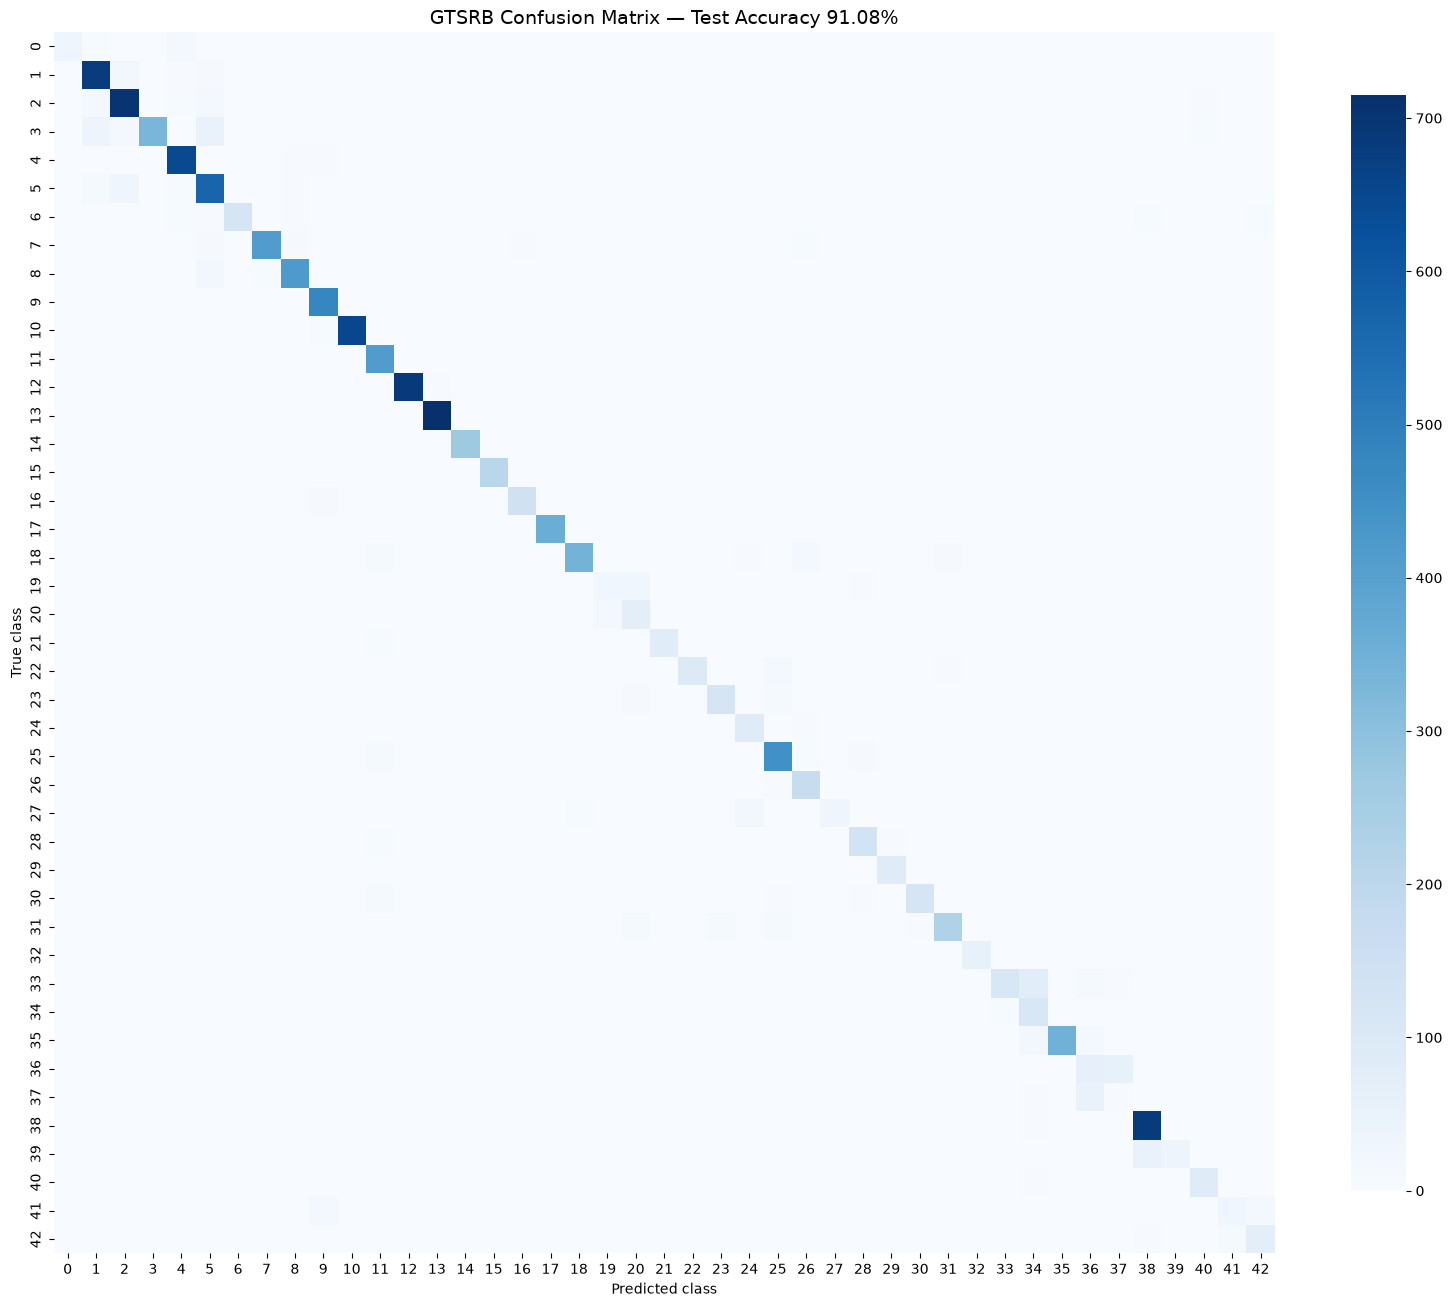

Confusion matrix saved: /workspace/outputs/gtsrb_vit/confusion_matrix.png

Top 10 confusions (true -> predicted, count):
  class 33 -> class 34 : 79
  class 36 -> class 37 : 57
  class 37 -> class 36 : 52
  class  3 -> class  5 : 52
  class 39 -> class 38 : 51
  class  3 -> class  1 : 38
  class  5 -> class  2 : 34
  class 19 -> class 20 : 27
  class  1 -> class  2 : 25
  class 35 -> class 34 : 22


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", square=True, cbar_kws={"shrink": 0.8})
plt.title(f"GTSRB Confusion Matrix — Test Accuracy {test_accuracy*100:.2f}%", fontsize=14)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print("Confusion matrix saved:", cm_path)

# Most-confused pairs — useful material for the dissertation discussion
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-cm_offdiag, axis=None), cm.shape))[0][:10]
print("\nTop 10 confusions (true -> predicted, count):")
for t, p in pairs:
    if cm_offdiag[t, p] > 0:
        print(f"  class {inverse_mapping[t]:>2} -> class {inverse_mapping[p]:>2} : {cm_offdiag[t, p]}")


## 12. Per-image predictions (dissertation appendix)

In [17]:
probs = tf.nn.softmax(raw_logits.astype("float32"), axis=1).numpy()

predictions_df = pd.DataFrame({
    "filename": test_df["Path"],
    "true_class_id": test_df["ClassId"],
    "predicted_class_id": [inverse_mapping[p] for p in y_pred],
    "confidence_pct": probs.max(axis=1) * 100,
    "correct": y_true == y_pred,
})
pred_csv = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions_df.to_csv(pred_csv, index=False)

print("Predictions saved:", pred_csv)
print(f"Correct: {predictions_df['correct'].sum()} / {len(predictions_df)}")
print(f"Mean confidence when correct  : {predictions_df.loc[predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
print(f"Mean confidence when incorrect: {predictions_df.loc[~predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
predictions_df.head()


Predictions saved: /workspace/outputs/gtsrb_vit/test_predictions.csv
Correct: 11503 / 12630
Mean confidence when correct  : 96.5%
Mean confidence when incorrect: 69.1%


,filename,true_class_id,predicted_class_id,confidence_pct,correct
0,Test/00000.png,16,16,99.969627,True
1,Test/00001.png,1,1,99.999443,True
2,Test/00002.png,38,38,99.949898,True
3,Test/00003.png,33,34,50.255524,False
4,Test/00004.png,11,11,99.999146,True


## 13. Download your results — **do this before stopping the pod**

Nothing leaves the pod automatically. Zip it, then download via the Jupyter file
browser (right-click → Download).


In [23]:
import shutil

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results", "zip", OUTPUT_DIR)
print("Zipped:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")
print()
print("Contents:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f:<40} {os.path.getsize(os.path.join(OUTPUT_DIR, f))/1e6:>8.1f} MB")
print()
print("Now: Jupyter file browser -> /workspace -> right-click")
print("'gtsrb_vit_results.zip' -> Download.")


Zipped: /workspace/gtsrb_vit_results.zip (3278.1 MB)

Contents:
  .ipynb_checkpoints                            1.0 MB
  classification_report.txt                     0.0 MB
  confusion_matrix.png                          0.1 MB
  gtsrb_vit_final.keras                       570.9 MB
  gtsrb_vit_final_v2.keras                   1030.6 MB
  phase1_head_best.keras                      344.1 MB
  phase2_finetuned_best.keras                 570.9 MB
  phase3_continued_best.keras                1030.6 MB
  test_predictions.csv                          0.4 MB
  training_curves.png                           0.1 MB
  training_history.csv                          0.0 MB

Now: Jupyter file browser -> /workspace -> right-click
'gtsrb_vit_results.zip' -> Download.


In [31]:
import os
print(os.listdir("/workspace"))

['gtsrb_vit_results.zip', 'data', 'outputs', '.ipynb_checkpoints', 'gtsrb_vit_runpod_v2_3.ipynb']


In [18]:
import shutil, os

# Keep only the final model + all the reports/plots/CSVs. Drop the redundant
# intermediate checkpoints (phase1, phase2, phase3, and the older pre-continuation
# gtsrb_vit_final.keras) — gtsrb_vit_final_v2.keras already IS the best result.
KEEP_ONLY = {
    # "gtsrb_vit_final_v2.keras",
    "classification_report.txt",
    "confusion_matrix.png",
    "test_predictions.csv",
    "training_curves.png",
    "training_history.csv",
}

light_dir = "/workspace/gtsrb_vit_results_light2"
os.makedirs(light_dir, exist_ok=True)
for fname in os.listdir(OUTPUT_DIR):
    if fname in KEEP_ONLY:
        shutil.copy2(os.path.join(OUTPUT_DIR, fname), os.path.join(light_dir, fname))

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results_light2", "zip", light_dir)
print("Lightweight zip:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")

Lightweight zip: /workspace/gtsrb_vit_results_light2.zip (0.3 MB)


### Alternative: download over SCP

From your own machine, using the **SSH over exposed TCP** details on the pod's
Connect page (that's the one that supports file transfer — the other SSH line
doesn't):

```powershell
scp -P <port> -i "C:\Users\Ragul Aaryah\runpod-ssd-key" root@<pod-ip>:/workspace/gtsrb_vit_results.zip .
```


## 14. Notes

**GPU choice — this one actually bites.** TensorFlow has no working kernels for
Blackwell (sm_120): RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. It's
an open TF bug, not a config problem. Pick Ada or Ampere:

| Safe (Ada / Ampere) | VRAM | Broken (Blackwell) |
|---|---|---|
| RTX 4090 | 24 GB | RTX 5090 |
| RTX 4000 Ada | 20 GB | RTX PRO 4000 Blackwell |
| L40S / L40 | 48 GB | RTX PRO 4500 Blackwell |
| L4 | 24 GB | RTX PRO 5000/6000 Blackwell |
| A100 | 40/80 GB | B200 |
| A6000 / A5000 / A40 | 24–48 GB | |
| RTX 3090 | 24 GB | |

On RunPod these mostly sit under **"NVIDIA previous generation"** — that section
is the safe one here, despite the name. The Section 1 smoke test will catch a
bad card in seconds.

**Pod lifecycle.** `Stop` preserves the volume disk; `Terminate` deletes it.
Always Stop, never Terminate, until the results zip is on your own machine.

If a restart offers to *migrate* the pod, that's RunPod telling you someone else
took your original physical GPU while you were stopped. Migration copies your
data to a new machine and is safe, but you get a new pod ID and IP.

**What's already done and won't repeat.** Sections 3–4 (download + PPM→PNG) are
one-time and skip themselves on re-runs, as long as the volume survives. So
future experiments start straight at Section 5.

**If you hit OOM.** Drop `BATCH_SIZE` to 64, restart the kernel, re-run from
Section 2 (the dataset prep will skip itself).

**Possible next experiment.** If you want a second result for the dissertation,
a ViT-Small vs ViT-Base comparison is more interesting than going bigger:
"comparable accuracy at a fraction of the compute" is a stronger finding on a
near-saturated benchmark than "bigger model, no change". Change the preset in
Section 8 and re-run.
